In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
def split_train_test(x, y, train_size=0.8, random_state=42):
    train_set_size = int(len(x) * train_size)
    
    np.random.seed(random_state)
    shuffled_indices = np.random.permutation(len(x))
        
    train_indices = shuffled_indices[:train_set_size]
    test_indices = shuffled_indices[train_set_size:]
    
    return x.iloc[train_indices], x.iloc[test_indices], y.iloc[train_indices], y.iloc[test_indices]

## Data Transformation

In [3]:
titanic_data = pd.read_csv("./input/titanic_survival.csv")
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [5]:
titanic_data = titanic_data.drop(columns=["Name", "PassengerId", "Ticket", "Cabin"])

age_median = titanic_data["Age"].median()
titanic_data["Age"] = titanic_data["Age"].fillna(age_median)

embarked_mode = titanic_data["Embarked"].mode()[0]
titanic_data["Embarked"] = titanic_data["Embarked"].fillna(embarked_mode)

titanic_data.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [6]:
x_train, x_test, y_train, y_test = split_train_test(titanic_data.drop("Survived", axis=1), titanic_data["Survived"])
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 7), (179, 7), (712,), (179,))

In [7]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,3,male,28.0,1,1,15.2458,C
439,2,male,31.0,0,0,10.5000,S
840,3,male,20.0,0,0,7.9250,S
720,2,female,6.0,0,1,33.0000,S
39,3,female,14.0,1,0,11.2417,C


In [8]:
x_survived = x_train[y_train == 1]
x_died = x_train[y_train == 0]

## Data Exploration Visualizations

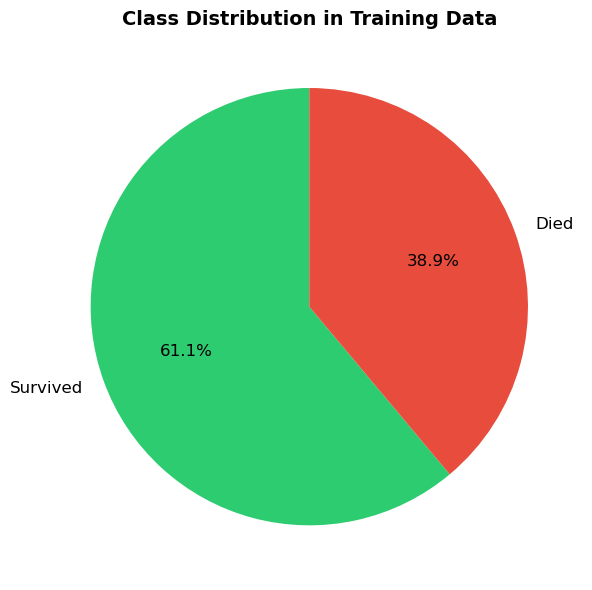

Survived: 277 (38.9%)
Died: 435 (61.1%)


In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

survived_counts = y_train.value_counts()
labels = ["Survived", "Died"]
colors = ["#2ecc71", "#e74c3c"]

ax.pie(survived_counts.values, labels=labels, autopct="%1.1f%%", 
       colors=colors, startangle=90, textprops={"fontsize": 12})
ax.set_title("Class Distribution in Training Data", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Survived: {survived_counts[1]} ({survived_counts[1]/len(y_train)*100:.1f}%)")
print(f"Died: {survived_counts[0]} ({survived_counts[0]/len(y_train)*100:.1f}%)")

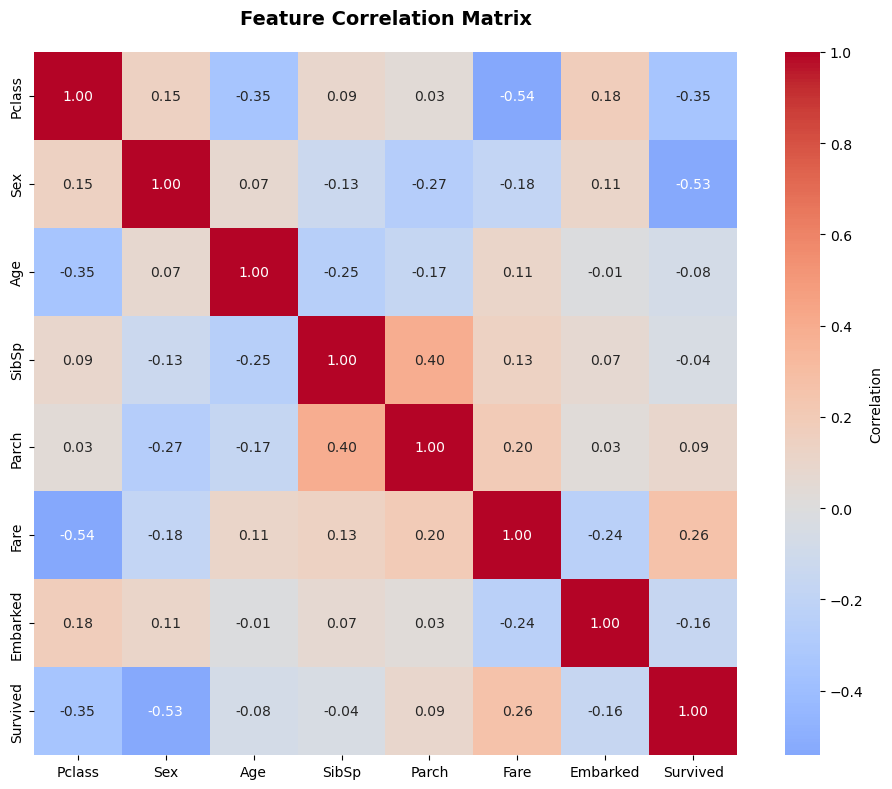

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

correlation_data = x_train.copy()
correlation_data["Sex"] = correlation_data["Sex"].replace({"male": 1, "female": 0})
correlation_data["Embarked"] = correlation_data["Embarked"].replace({"C": 0, "Q": 1, "S": 2})
correlation_data["Survived"] = y_train.values

correlation_matrix = correlation_data.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, square=True, ax=ax, cbar_kws={"label": "Correlation"})
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

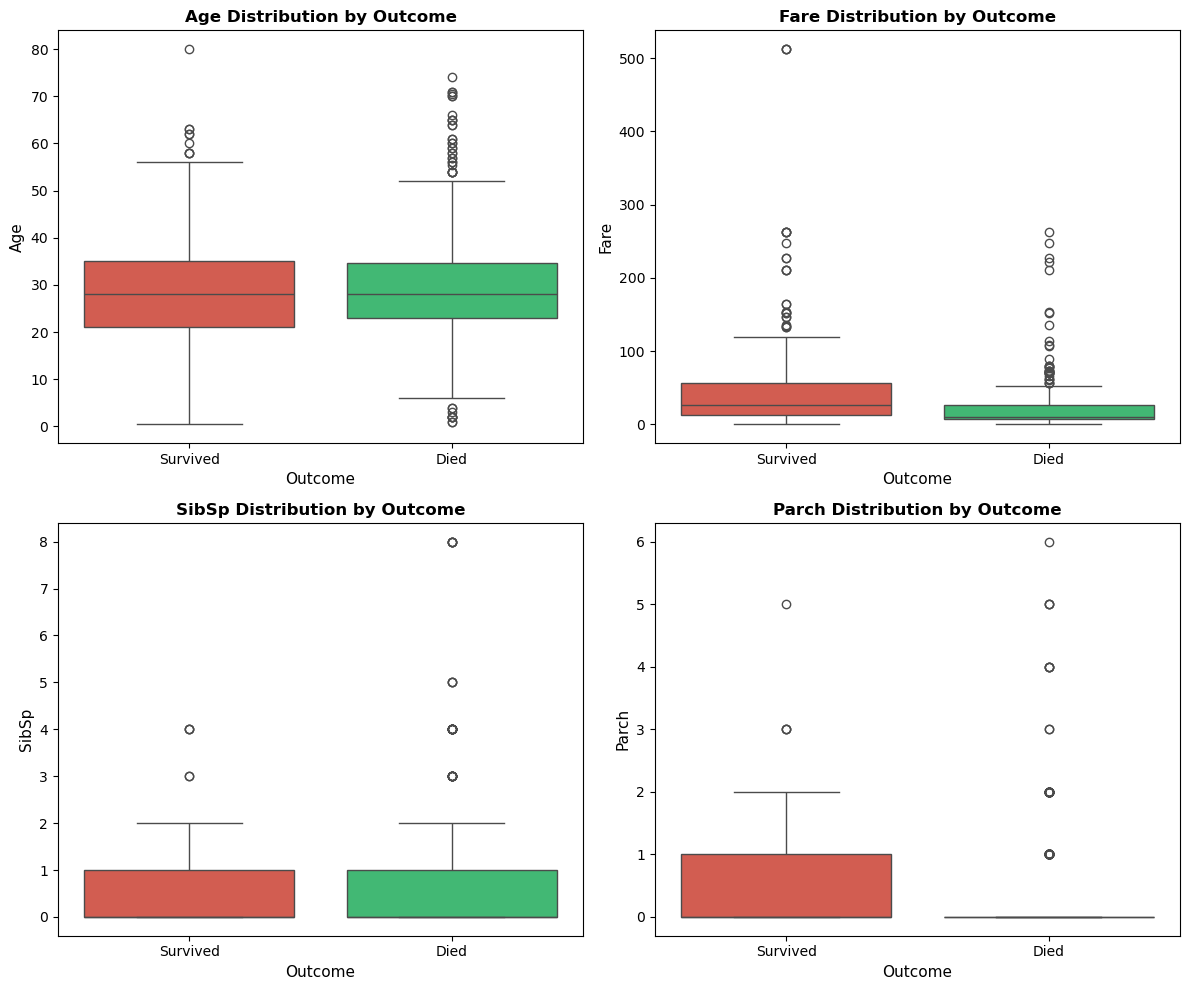

In [11]:
numeric_features = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

viz_data = x_train.copy()
viz_data["Survived"] = y_train.values
viz_data["Outcome"] = viz_data["Survived"].map({1: "Survived", 0: "Died"})

for idx, feature in enumerate(numeric_features):
    sns.boxplot(data=viz_data, x="Outcome", y=feature, ax=axes[idx], 
                palette=["#e74c3c", "#2ecc71"])
    axes[idx].set_title(f"{feature} Distribution by Outcome", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Outcome", fontsize=11)
    axes[idx].set_ylabel(feature, fontsize=11)

plt.tight_layout()
plt.show()

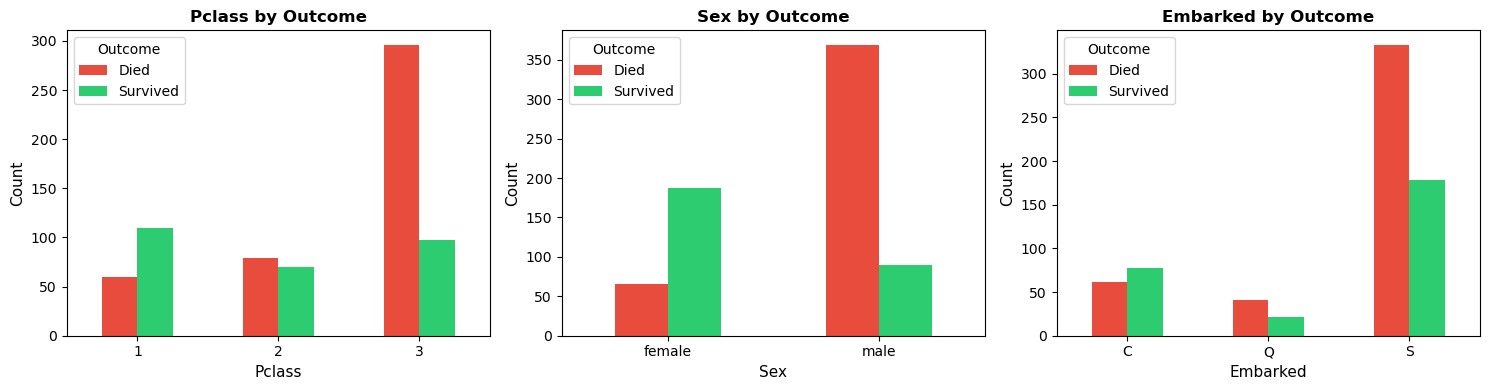

In [12]:
categorical_features = ["Pclass", "Sex", "Embarked"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feature in enumerate(categorical_features):
    crosstab_data = pd.crosstab(viz_data[feature], viz_data["Outcome"])
    
    crosstab_data.plot(kind="bar", ax=axes[idx], color=["#e74c3c", "#2ecc71"])
    axes[idx].set_title(f"{feature} by Outcome", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel("Count", fontsize=11)
    axes[idx].legend(title="Outcome", fontsize=10)
    axes[idx].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Model Training

In [13]:
survived_prior = len(x_survived) / len(x_train)
died_prior = len(x_died) / len(x_train)

priors = {
    1: survived_prior,
    0: died_prior
}

In [14]:
gaussian_columns = ["Fare", "Age"]
x_survived_gaussian = x_survived[gaussian_columns]
x_died_gaussian = x_survived[gaussian_columns]

x_survived_means = np.mean(x_survived_gaussian, axis=0)
x_survived_vars = np.var(x_survived_gaussian, axis=0)

x_died_means = np.mean(x_died_gaussian, axis=0)
x_died_vars = np.var(x_died_gaussian, axis=0)

means = {
    1: x_survived_means,
    0: x_died_means
}

variances = {
    1: x_survived_vars,
    0: x_died_vars
}

In [15]:
def compute_gaussian_probability(x, feature_name):
    survived_feature_mean = means[1][feature_name]
    died_feature_mean = means[0][feature_name]
    
    survived_feature_var = variances[1][feature_name]
    died_feature_var = variances[0][feature_name]
    
    a1 = 1 / np.sqrt(2 * np.pi * survived_feature_var)
    b1 = (x[feature_name] - survived_feature_mean) ** 2
    c1 = 2 * survived_feature_var
    
    survived_feature_prob = a1 * np.exp(-b1 / c1)
    
    a2 = 1 / np.sqrt(2 * np.pi * died_feature_var)
    b2 = (x[feature_name] - died_feature_mean) ** 2
    c2 = 2 * died_feature_var
    
    died_feature_prob = a2 * np.exp(-b2 / c2)
    
    return survived_feature_prob, died_feature_prob

In [16]:
categorical_columns = ["Pclass", "Sex", "Embarked", "SibSp", "Parch"]

x_survived_categorical = x_survived[categorical_columns]
x_died_categorical = x_died[categorical_columns]

x_survived_category_counts = {
    "Sex": x_survived_categorical["Sex"].value_counts(),
    "Pclass": x_survived_categorical["Pclass"].value_counts(),
    "Embarked": x_survived_categorical["Embarked"].value_counts(),
    "SibSp": x_survived_categorical["SibSp"].value_counts(),
    "Parch": x_survived_categorical["Parch"].value_counts()
}

x_died_category_counts = {
    "Sex": x_died_categorical["Sex"].value_counts(),
    "Pclass": x_died_categorical["Pclass"].value_counts(),
    "Embarked": x_died_categorical["Embarked"].value_counts(),
    "SibSp": x_died_categorical["SibSp"].value_counts(),
    "Parch": x_died_categorical["Parch"].value_counts()
}

In [17]:
def compute_categorical_probability(x, feature_name, smoothing=1.0):
    vocab_size = len(x_survived_category_counts[feature_name])
    
    survived_category_frequency = x_survived_category_counts[feature_name].get(x[feature_name], 0)
    died_category_frequency = x_died_category_counts[feature_name].get(x[feature_name], 0)
    
    survived_total_frequency = x_survived_category_counts[feature_name].sum()
    died_total_frequency = x_died_category_counts[feature_name].sum()
    
    a1 = survived_category_frequency + smoothing
    b1 = survived_total_frequency + (smoothing * vocab_size) 
    
    survived_feature_prob = a1 / b1
    
    a2 = died_category_frequency + smoothing
    b2 = died_total_frequency + (smoothing * vocab_size)
    
    died_feature_prob = a2 / b2
    
    return survived_feature_prob, died_feature_prob

In [18]:
def compute_class_probabilities(x):
    survived_score = np.log(priors[1])
    died_score = np.log(priors[0])
    
    for feature_name in x.index:
        if feature_name in categorical_columns:
            survived_feature_prob, died_feature_prob = compute_categorical_probability(x, feature_name)
        else:    
            survived_feature_prob, died_feature_prob = compute_gaussian_probability(x, feature_name)
        
        survived_score += np.log(survived_feature_prob)
        died_score += np.log(died_feature_prob)
    
    return survived_score, died_score

## Model Evaluation

In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [20]:
predictions = []
probabilities = []

for idx, x in x_test.iterrows():
    survived_score, died_score = compute_class_probabilities(x)
    prediction = survived_score > died_score
    predictions.append(prediction)
    
    prob_survived = 1 / (1 + np.exp(-(survived_score - died_score)))
    probabilities.append(prob_survived)

predictions = np.array(predictions)
probabilities = np.array(probabilities)
y_test_array = y_test.values

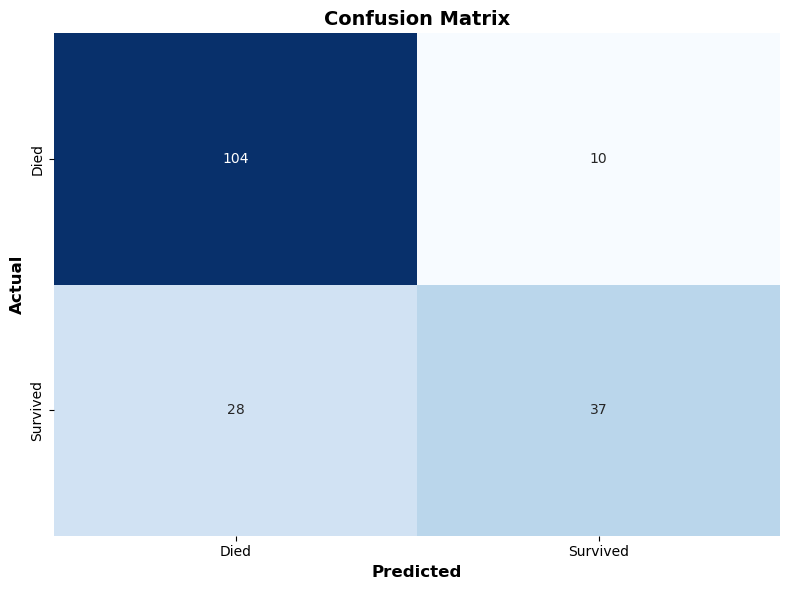

True Negatives: 104
False Positives: 10
False Negatives: 28
True Positives: 37

Sensitivity (Recall): 0.5692
Specificity: 0.9123
Precision: 0.7872


In [21]:
cm = confusion_matrix(y_test_array, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
ax.set_xlabel("Predicted", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual", fontsize=12, fontweight="bold")
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

tn_val, fp_val, fn_val, tp_val = cm.ravel()
sensitivity = tp_val / (tp_val + fn_val)
specificity = tn_val / (tn_val + fp_val)
precision = tp_val / (tp_val + fp_val)

print(f"True Negatives: {tn_val}")
print(f"False Positives: {fp_val}")
print(f"False Negatives: {fn_val}")
print(f"True Positives: {tp_val}")
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")

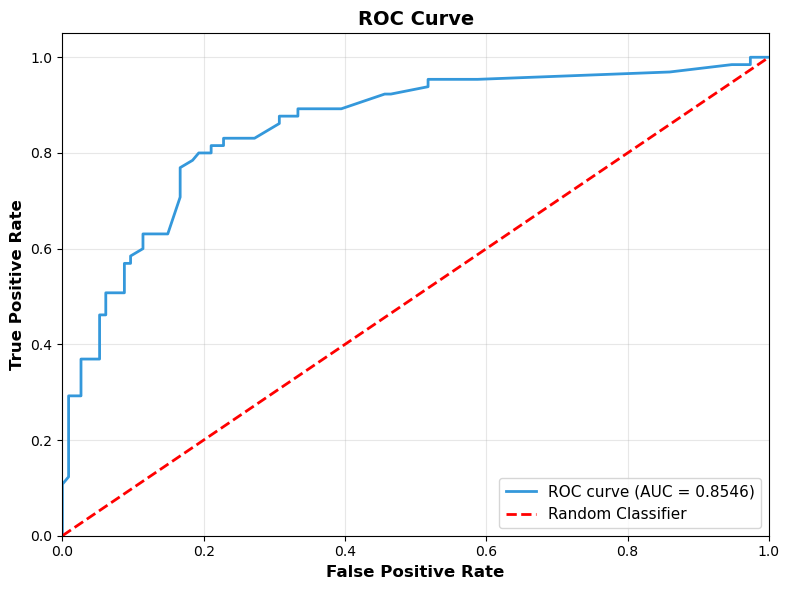

Area Under the Curve (AUC): 0.8546


In [22]:
fpr, tpr, thresholds = roc_curve(y_test_array, probabilities)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#3498db", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12, fontweight="bold")
ax.set_ylabel("True Positive Rate", fontsize=12, fontweight="bold")
ax.set_title("ROC Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.4f}")